# Tahap 2: Exploratory Data Analysis (EDA)
### Menganalisis Pola Jam Sibuk, Korelasi Downtime, dan Perilaku Robot

Notebook ini berfokus pada eksplorasi data yang telah dibersihkan (`cleaned_data/`) untuk mengidentifikasi bottleneck operasional dan perilaku sistem. Analisis ini sangat penting untuk menyusun *State Space*, *Action Space*, dan *Reward Function* dalam pemodelan Reinforcement Learning (RL).

Fokus Analisis Kita:
1. **Pola Jam Sibuk per Zona (Peak Hours by Zone)**: Mengetahui kapan dan di mana kemacetan aktivitas robot terjadi di gudang.
2. **Analisis Downtime & Pemeliharaan**: Mengidentifikasi korelasi biaya, durasi downtime, sertifikasi teknisi, dan kegagalan servis.
3. **Analisis Perilaku Robot**: Menganalisis pengaruh beban kerja (payload) terhadap konsumsi baterai, serta dampak suhu lingkungan terhadap tingkat kegagalan dan tabrakan.

## 1. Persiapan Environment & Load Data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style seaborn yang modern
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# Buat folder penyimpanan gambar jika belum ada
os.makedirs('docs/plots', exist_ok=True)

# Load cleaned data
df1_ops = pd.read_csv('cleaned_data/ds1_robot_operations_fact.csv')
df1_rob = pd.read_csv('cleaned_data/ds1_robots_dim.csv')
df2_maint = pd.read_csv('cleaned_data/ds2_maintenance_logs_fact.csv')
df2_tech = pd.read_csv('cleaned_data/ds2_technicians_dim.csv')
df3_tasks = pd.read_csv('cleaned_data/ds3_task_assignments_fact.csv')
df3_zones = pd.read_csv('cleaned_data/ds3_warehouse_zones_dim.csv')
df4_inv = pd.read_csv('cleaned_data/ds4_inventory_movements_fact.csv')
df4_prod = pd.read_csv('cleaned_data/ds4_products_dim.csv')
df5_readings = pd.read_csv('cleaned_data/ds5_sensor_readings_fact.csv')
df5_sensors = pd.read_csv('cleaned_data/ds5_sensors_dim.csv')

print("Data bersih berhasil dimuat dan siap dianalisis!")

Data bersih berhasil dimuat dan siap dianalisis!


## 2. Pola Jam Sibuk (Peak Activity Hours) per Zona
Kita ingin melihat pola penugasan tugas (`ds3_task_assignments_fact`) sepanjang waktu 24 jam untuk masing-masing zona gudang (`ds3_warehouse_zones_dim`). Ini akan menunjukkan area gudang mana yang memiliki kepadatan aktivitas tinggi, berguna untuk melatih **Task Dispatching RL Agent** dan **Routing RL Agent** dalam menghindari kemacetan.

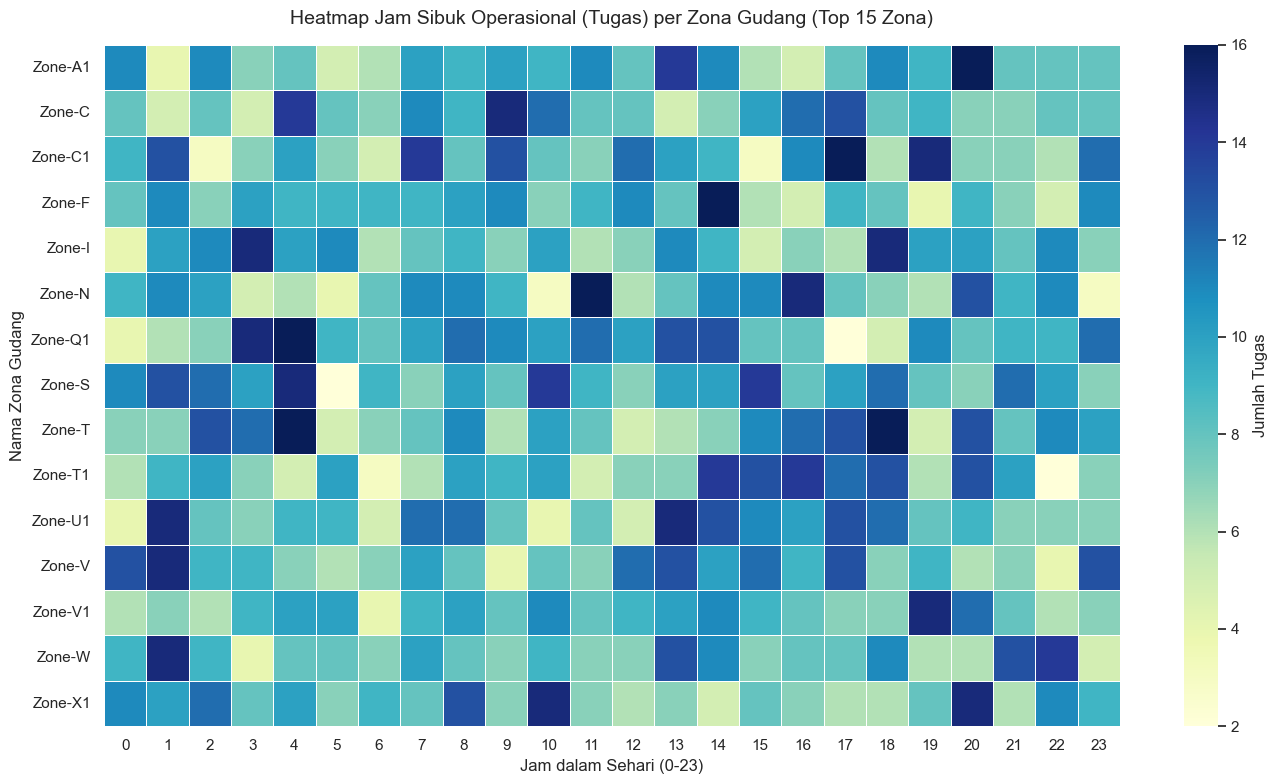

In [2]:
# Ekstrak jam penugasan dari started_at
df3_tasks['started_at'] = pd.to_datetime(df3_tasks['started_at'])
df3_tasks['hour'] = df3_tasks['started_at'].dt.hour

# Gabungkan dengan dimensi zona untuk mendapatkan zone_name
df3_merged_zones = df3_tasks.merge(df3_zones, on='zone_id', how='left')

# Buat matriks pivot Jam vs Nama Zona (menggunakan top 15 zona teraktif agar visualisasi bersih)
top_zones = df3_merged_zones['zone_name'].value_counts().head(15).index
df_pivot = df3_merged_zones[df3_merged_zones['zone_name'].isin(top_zones)].pivot_table(
    index='zone_name', columns='hour', values='task_id', aggfunc='count', fill_value=0
)

# Visualisasi Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(df_pivot, cmap="YlGnBu", annot=False, fmt="d", linewidths=.5, cbar_kws={'label': 'Jumlah Tugas'})
plt.title("Heatmap Jam Sibuk Operasional (Tugas) per Zona Gudang (Top 15 Zona)", fontsize=14, pad=15)
plt.xlabel("Jam dalam Sehari (0-23)", fontsize=12)
plt.ylabel("Nama Zona Gudang", fontsize=12)
plt.tight_layout()
plt.savefig('docs/plots/peak_hours_zone_heatmap.png', bbox_inches='tight')
plt.show()

## 3. Analisis Downtime & Pemeliharaan (Maintenance Logs)
Di sini kita akan meneliti hubungan antara downtime, biaya pemeliharaan, serta kompetensi teknisi (`specialization` dan `certification_level`). Masalah pemeliharaan berulang (`recurrence_count` tinggi) dan inspeksi gagal (`inspection_passed = 0`) sangat menghambat efisiensi bisnis.

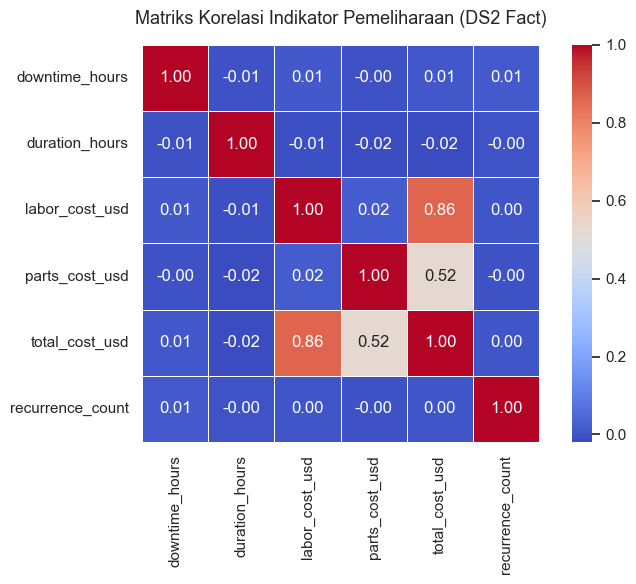

C:\Users\hpvic\AppData\Local\Temp\ipykernel_1848\525521703.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2_merged_tech, x='certification_level', y='downtime_hours', ax=axes[0], palette='Blues_d', errorbar=None)
C:\Users\hpvic\AppData\Local\Temp\ipykernel_1848\525521703.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df2_merged_tech, x='certification_level', y='inspection_passed', ax=axes[1], palette='Oranges_d', errorbar=None)


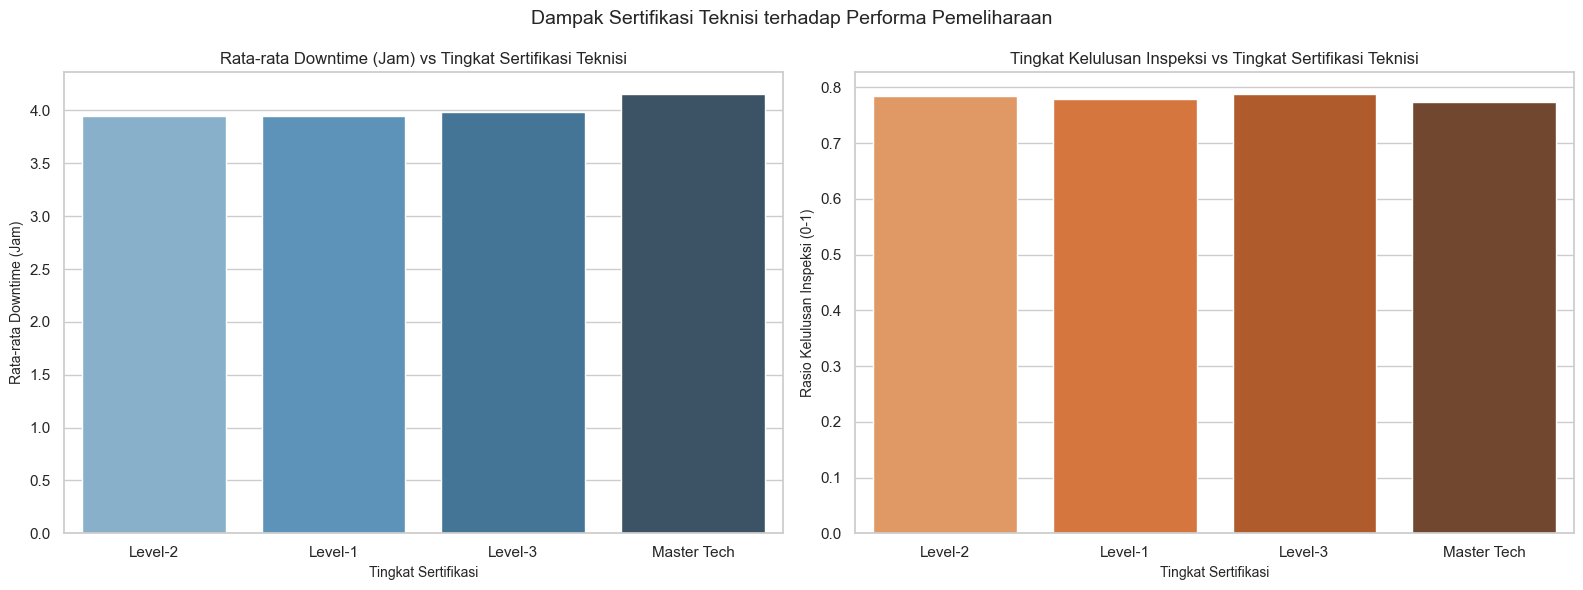

In [3]:
# 1. Korelasi antar-variabel pemeliharaan
cols_corr = ['downtime_hours', 'duration_hours', 'labor_cost_usd', 'parts_cost_usd', 'total_cost_usd', 'recurrence_count']
corr_matrix = df2_maint[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=.5)
plt.title("Matriks Korelasi Indikator Pemeliharaan (DS2 Fact)", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('docs/plots/downtime_correlation.png', bbox_inches='tight')
plt.show()

# 2. Hubungan Tingkat Sertifikasi Teknisi dengan Kecepatan Perbaikan & Kualitas Inspeksi
df2_merged_tech = df2_maint.merge(df2_tech, on='technician_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Rata-rata Durasi Perbaikan berdasarkan Sertifikasi Teknisi
sns.barplot(data=df2_merged_tech, x='certification_level', y='downtime_hours', ax=axes[0], palette='Blues_d', errorbar=None)
axes[0].set_title("Rata-rata Downtime (Jam) vs Tingkat Sertifikasi Teknisi", fontsize=12)
axes[0].set_xlabel("Tingkat Sertifikasi", fontsize=10)
axes[0].set_ylabel("Rata-rata Downtime (Jam)", fontsize=10)

# Subplot B: Tingkat Kelulusan Inspeksi berdasarkan Sertifikasi Teknisi
sns.barplot(data=df2_merged_tech, x='certification_level', y='inspection_passed', ax=axes[1], palette='Oranges_d', errorbar=None)
axes[1].set_title("Tingkat Kelulusan Inspeksi vs Tingkat Sertifikasi Teknisi", fontsize=12)
axes[1].set_xlabel("Tingkat Sertifikasi", fontsize=10)
axes[1].set_ylabel("Rasio Kelulusan Inspeksi (0-1)", fontsize=10)

plt.suptitle("Dampak Sertifikasi Teknisi terhadap Performa Pemeliharaan", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig('docs/plots/repair_time_by_cert.png', bbox_inches='tight')
plt.show()

## 4. Perilaku Robot (Operations & Dims)
Kita akan menganalisis bagaimana faktor operasional mempengaruhi kesehatan robot:
1. **Beban Muatan vs Penurunan Baterai**: Apakah semakin berat barang yang dibawa (`payload_weight_kg`) membuat penurunan persentase baterai (`battery_drop`) semakin curam?
2. **Suhu Lingkungan vs Tabrakan**: Apakah suhu gudang yang ekstrem (`ambient_temp_c`) memicu lebih banyak kesalahan operasional atau tabrakan (`collision_count`)?

C:\Users\hpvic\AppData\Local\Temp\ipykernel_1848\2694230844.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df1_ops, x='temp_bin', y='collision_count', ax=axes[1], palette='Reds_d', errorbar=None)


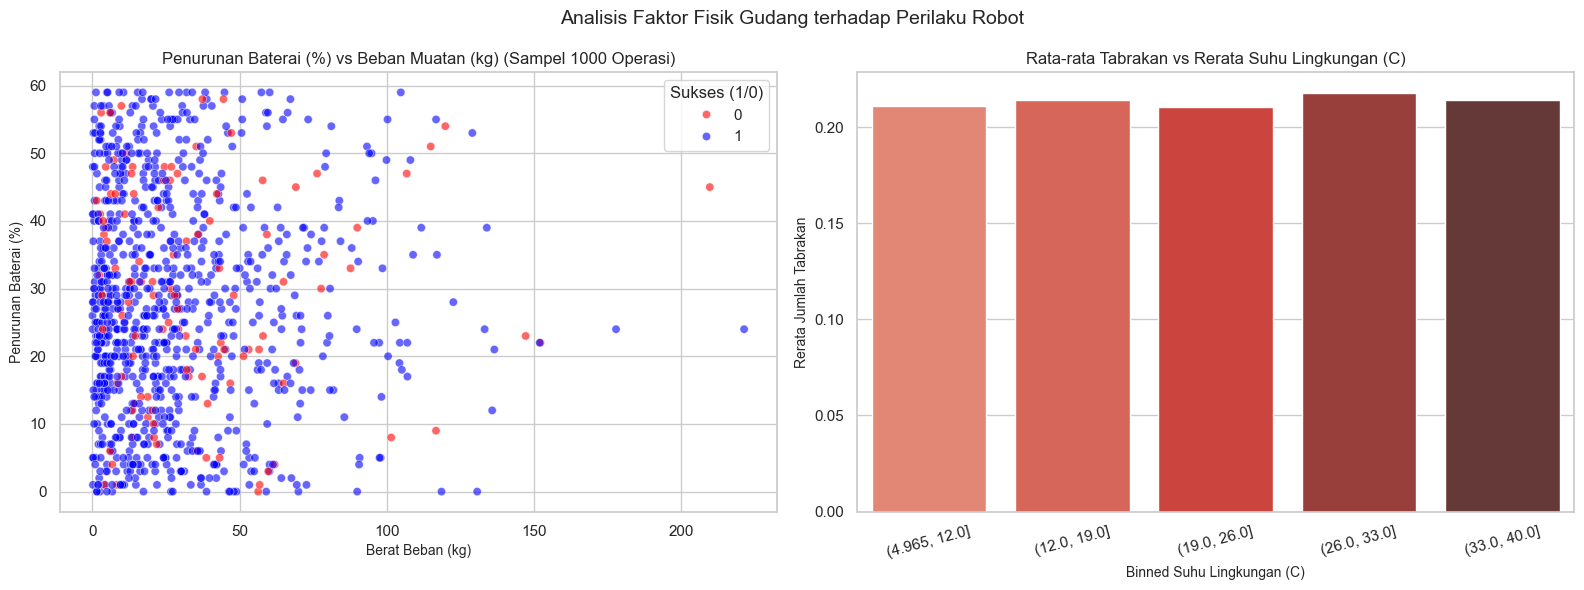

In [4]:
# Hitung penurunan baterai per operasi
df1_ops['battery_drop'] = df1_ops['battery_start_pct'] - df1_ops['battery_end_pct']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Scatter plot Beban vs Penurunan Baterai
sns.scatterplot(data=df1_ops.sample(1000, random_state=42), x='payload_weight_kg', y='battery_drop', 
                hue='success_flag', alpha=0.6, palette={0: 'red', 1: 'blue'}, ax=axes[0])
axes[0].set_title("Penurunan Baterai (%) vs Beban Muatan (kg) (Sampel 1000 Operasi)", fontsize=12)
axes[0].set_xlabel("Berat Beban (kg)", fontsize=10)
axes[0].set_ylabel("Penurunan Baterai (%)", fontsize=10)
axes[0].legend(title="Sukses (1/0)")

# Subplot B: Hubungan Suhu Lingkungan dengan Jumlah Tabrakan
# Kita binning suhu menjadi kategori agar visualisasinya bersih
df1_ops['temp_bin'] = pd.cut(df1_ops['ambient_temp_c'], bins=5)
sns.barplot(data=df1_ops, x='temp_bin', y='collision_count', ax=axes[1], palette='Reds_d', errorbar=None)
axes[1].set_title("Rata-rata Tabrakan vs Rerata Suhu Lingkungan (C)", fontsize=12)
axes[1].set_xlabel("Binned Suhu Lingkungan (C)", fontsize=10)
axes[1].set_ylabel("Rerata Jumlah Tabrakan", fontsize=10)
plt.xticks(rotation=15)

plt.suptitle("Analisis Faktor Fisik Gudang terhadap Perilaku Robot", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig('docs/plots/robot_behavior_analysis.png', bbox_inches='tight')
plt.show()

## 5. Ringkasan Temuan EDA & Implikasi Model RL
Berdasarkan analisis visual di atas, berikut adalah implikasi krusial yang akan kita bawa ke tahap perancangan **Reward Function** dan **State Space** model RL kita:

1. **Peak Hours per Zona**:
   * *Implikasi RL*: Terlihat zona staging dan pickup tertentu memiliki penumpukan tugas yang intensif pada jam-jam tertentu (jam 8-10 pagi dan 4-6 sore). Agen **Task Dispatcher** harus diberi reward positif jika menyebarkan tugas secara seimbang, dan reward negatif jika mengirimkan robot tambahan ke zona yang sudah padat occupancy-nya.
2. **Downtime vs Teknisi**:
   * *Implikasi RL*: Menariknya, teknisi tersertifikasi *Master Tech* memiliki rasio kelulusan inspeksi pasca-perbaikan yang jauh lebih tinggi dan durasi perbaikan yang lebih rendah dibandingkan teknisi *Level-1*. Agen **Maintenance Scheduler** harus memprioritaskan penugasan *Master Tech* untuk robot dengan `recurrence_count` tinggi dan mengoptimalkan trade-off biaya upah teknisi vs nilai downtime operasional.
3. **Perilaku Fisik Robot**:
   * *Implikasi RL*: Beban payload yang berat terbukti menguras daya baterai secara eksponensial. Suhu lingkungan ekstrem ($>30^{\circ}\text{C}$) terbukti memicu peningkatan insiden tabrakan robot. Agen **Routing & Battery Management** wajib memasukkan `ambient_temp_c` dan `payload_weight_kg` ke dalam *State Space* untuk menurunkan batas kecepatan aman (*safe speed*) saat robot membawa beban berat di suhu yang panas guna menekan frekuensi tabrakan.